# Homework 4: Working with data using Pandas and Fitting data with a model

### <p style="text-align: right;"> &#9989; Put your name here.


<img src="https://www.lifegate.com/app/uploads/wine-grapes.jpg"
     alt="Image of grapevines"
     align="center" 
     height="300" 
      />
     
Image credit: https://www.lifegate.com/people/news/climate-change-wine-production


## Goals

The main goals of this homework are 

1. Extracting information from datasets
2. Cleaning data with `pandas`
3. Visualizing data with `seaborn`
4. Fitting data using `curve_fit`

To achieve these goals we will be using two different datasets; `grape_harvest.csv` and `stars.csv`

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Saturday, April 4.** It should be uploaded into the "Homework Assignments" submission folder for Homework #4.  Submission instructions can be found at the end of the notebook.

**Full disclosure**: The first two parts of this exam were created in collaboration with a professor in horticulture with an interest in wine and I am an expert in neither!

## Grading

* Exploring the grape harvest data (**25 points**)
    - 1.1 Loading and inspecting the data (5 points)
    - 1.2 Determining the earliest and latest harvest dates and where they occurred (5 points)
    - 1.3 Finding median harvest dates in 50 year intervals (4 points)
    - 1.4 Visualizing trends by region (11 points)
* Stars: Exploratory Data Analysis (**17 points**)
    - 2.1 Loading and inspecting the data (2 points)
    - 2.2 Looking for correlations (2 points)
    - 2.3 Grouping by (3 points)
    - 2.4 Visual representation of correlations (10 points)
* Fitting curves to data: (**16 points**)
    - 3.1 Choosing a model (6 points)
    - 3.2 Fit the model (7 points)
    - 3.3 Check your model (3 points)

**Total**: 58 points

---
## Part 1: Exploring the grape harvest data (25 points total)

### 1.1: Loading and inspecting the data (5 points)

After visiting Traverse City and sampling Michigan wines, you decide that you would like to start a vineyard in Michigan. You've seen the vineyards in Traverse City and know that, although it is possible to grow wine grapes there, that sometimes it is too cold. You wonder if because of climate change, Michigan might soon have a warmer, more suitable climate for growing grapes. 

You know that Europe has a long history of growing grapes, and you wonder if they kept records that might indicate how grapes respond to changes in temperature. You find a [study](https://www.clim-past.net/8/1403/2012/cp-8-1403-2012.pdf) that has compiled numerous records of grape harvest dates for more than four centuries and also a [database](http://www.climatemonitor.it/?page_id=40210&lang=en) of temperature anomalies in Europe dating back to 1655.

**Using the provided dataset, `grape_harvest.csv`, you're going to explore how the European grape harvest date changes with respect to temperature across centuries of data.**

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.optimize import curve_fit

&#9989; **Task: (2 points)** Read in the grape harvest data file as a pandas dataframe and display the first 10 rows

In [2]:
# Read in the grape harvest data here


In [3]:
### ANSWER ###

# 1 point for reading 
# 1 point for displaying the first 10 rows.

# Read in the grape harvest data here
data = pd.read_csv("grape_harvest.csv")
data.head(10) 

,year,region,harvest,anomaly
0,1700,alsace,42.9,-0.91
1,1701,alsace,35.9,-0.76
2,1702,alsace,45.0,-1.40
3,1703,alsace,49.4,-1.21
4,1704,alsace,30.4,-0.44
5,1705,alsace,46.9,-0.76
6,1706,alsace,38.7,-1.04
7,1707,alsace,44.0,-1.30
8,1708,alsace,32.0,-1.51
9,1709,alsace,29.9,-2.13


&#9989; **Task: (4 points)** Now, write some code to inspect some of the properties of the data and then answer the following questions:

* Use a command to look at summary statistics (like the count, min, max, and mean) for columns with continuous data
* What are the names of the columns?
* How many rows are in this dataset?
* How many different (or `unique`) regions are in the dataset

In [4]:
# Put your code here


*Put your answer here*

### ANSWER ###
1 point for each correct answer, 0 for incorrect answer
- Q1. Use describe()
- Q2. `'year', 'region', 'harvest', 'anomaly'`. Note that the describe function does not have region because it is a categorical variable
- Q3. 4732. Can also use code to get the answer. 
- Q4. `data["region"].unique() = 27`

In [5]:
### ANSWER ###
data.describe()
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 4732 entries, 0 to 4731
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     4732 non-null   int64  
 1   region   4732 non-null   str    
 2   harvest  4732 non-null   float64
 3   anomaly  4732 non-null   float64
dtypes: float64(2), int64(1), str(1)
memory usage: 148.0 KB


In [6]:
### ANSWER ###
print(f"There are {len(data['region'].unique())} unique regions in the dataset.")
data.describe()


There are 27 unique regions in the dataset.


,year,harvest,anomaly
count,4732.000000,4732.000000,4732.000000
mean,1832.835376,33.959510,-0.337811
std,91.713152,11.807714,0.675309
min,1655.000000,-13.000000,-2.470000
25%,1762.000000,25.900000,-0.750000
50%,1834.500000,34.000000,-0.280000
75%,1903.000000,42.600000,0.060000
max,2007.000000,75.000000,1.460000


### 1.2: Determining the earliest and latest harvest dates and where they occurred (5 points)

The `pandas` dataframe you just created should have four columns, which are:

* **'year'**: the year the data was collected
* **'region'**: the region in Europe that the data was collected from
* **'harvest'**: the harvest date recorded. Harvest date is defined as number of days after August 31st. A negative number means the grapes were harvested before August 31st that year, and a positive number after.
* **'anomaly'**: the temperature anomaly. For a given year, this number represents how much colder (negative) or hotter (positive) Europe was compared to a long term reference value, in degrees Celsius

We'll start off our exploration of grape harvest dates by figuring out when and where the earliest and latest harvest dates occurred.

&#9989; **Task: (5 points)** Below, print out statements answering the following questions using masking techniques that you have learned:

1. Which year did the earliest harvest happen, which region did it occur in, and how early was the harvest?

2. Which year did the latest harvest happen, which region did it occur in, and how late was the harvest?


In [7]:
# Put your code here

In [8]:
### ANSWER ###
year = data['year'][data['harvest'] == data['harvest'].min()].values[0]
region = data['region'][data['harvest'] == data['harvest'].min()].values[0]
days = data['harvest'].min()

print(f"The earliest harvest was from the region {region} with {days:.0f} days before August 31st in year {year}")
# 3 points for getting region,days,year correct (1 point each) 
# 1 point for printing a full sentence

The earliest harvest was from the region champagne_2 with -13 days before August 31st in year 1822


In [28]:
### ANSWER ###
year = data['year'][data['harvest'] == data['harvest'].max()].values[0]
region = data['region'][data['harvest'] == data['harvest'].max()].values[0]
days = data['harvest'].max()



print(f"The lates harvest was from the region {region} with {days:.0f} days after August 31st in year {year}")
# 1 point for understanding that they need to use max instead of min. 


The lates harvest was from the region luxembourg with 75 days after August 31st in year 1851


### 1.3 Finding median harvest dates in 50 year intervals (4 points)

You want to know if the grape harvest date is changing, and if so, is it getting earlier or later?

You decide that you would like to know the median grape harvest date for the following 50 year intervals, as well as the median since the year 2000:

* 1800-1849
* 1850-1899
* 1900-1949
* 1950-1999
* 2000-2007

&#9989; **Task:** For each of the above intervals, calculate the **median** grape harvest date. For each interval print out statements saying

`"The median harvest date for years (*insert interval here*) is: x"`.

**Is the harvest date for grapes getting earlier or later?**


In [10]:
# Put your code here


*Put your answer here*

In [11]:
### ANSWER ###

# 1 point for calculating the median and not the mean
# 1 point for printing all the dates.
# 1 point for answering the earlier/later question
# 1 point for using masks

# Easy solution

# median_1800_1849 = data['harvest'][ (data['year'] >= 1800) & (data['year'] <= 1849) ].median()
# median_1850_1899 = data['harvest'][ (data['year'] >= 1850) & (data['year'] <= 1899) ].median()
# median_1900_1949 = data['harvest'][ (data['year'] >= 1900) & (data['year'] <= 1949) ].median()
# median_1950_1999 = data['harvest'][ (data['year'] >= 1950) & (data['year'] <= 1999) ].median()
# median_2000_2007 = data['harvest'][ (data['year'] >= 2000) & (data['year'] <= 2007) ].median()

# print("The mean harvest date from 1800_1849 was", median_1800_1849)
# print("The mean harvest date from 1850_1899 was", median_1850_1899)
# print("The mean harvest date from 1900_1949 was", median_1900_1949)
# print("The mean harvest date from 1950_1999 was", median_1950_1999)
# print("The mean harvest date from 2000_2007 was", median_2000_2007)

# Expert solution
year = 1800
interval = 50 # years
while year < 2007:
    min_year = year
    max_year = year + interval
    mask = data["year"] >= min_year 
    mask_2 = data["year"] < max_year
    median = data["harvest"][mask & mask_2].median()
    if max_year> 2007:
        max_year = 2007
    print(f"The median harvest day for years {min_year}-{max_year} was {median:.1f}")
    year += interval
    
print(f"The median harvest date is getting earlier")

The median harvest day for years 1800-1850 was 36.0
The median harvest day for years 1850-1900 was 33.8
The median harvest day for years 1900-1950 was 27.9
The median harvest day for years 1950-2000 was 28.0
The median harvest day for years 2000-2007 was 19.9
The median harvest date is getting earlier


### 1.4 Visualizing trends by region (11 points)

Now that you understand a bit about the overall trends in the data, you want to examine other factors that might influence grape harvest date besides historical changes in climate.

You see that the data comes from many regions, all the way from sunny Spain to Germany. You wonder if these latitudinal differences would have any effect on the grape harvest dates.

&#9989; **Task: (5 points)** Make a boxplot comparing the ditributions of grape harvest dates where the x-axis is "region" and the y-axis "harvest". The regions will be ordered by latitude, from the most southern to northern. This will allow you to assess visually if latitude is affecting grape harvest date.

Your plot should:

1. have a figure of size (15, 4)
2. include axis labels
3. have a title
4. the $x$ axis ticks should be rotated by 90 degrees
5. finally, arrange the regions by latitude, from the most southern to the most northern. To do this, use the provided list `latitude_order`. Within `seaborn` boxplot function, specify the `order` argument as follows: `order = latitude_order`. This will arrange the regions in your boxplot from the most southern to northern.

**Hint:** Here is the [link](https://seaborn.pydata.org/generated/seaborn.boxplot.html#seaborn.boxplot) to `boxplot`'s documentation. You want to get a plot like this (the color is optional)

![harvestplot](https://raw.githubusercontent.com/msu-cmse-courses/cmse801-supplemental/main/Homework/HW04/harvest_plot.png)

In [12]:
## DO NOT DELETE THE PROVIDED LINES OF CODE

# list of regions,  ordered from the most southern to most northern 
latitude_order = ['spain','maritime_alps','languedoc','various_south_east',
                  'gaillac_south_west','southern_rhone_valley','bordeaux',
                  'northern_rhone_valley','auvergne','savoie','northern_italy',
                  'beaujolais_maconnais','vendee_poitou_charente','switzerland_leman_lake',
                  'jura','high_loire_valley','low_loire_valley','burgundy','auxerre_avalon',
                  'champagne_2','southern_lorraine','alsace','northern_lorraine',
                  'germany','ile_de_france','champagne_1','luxembourg'] 
                    
# Put your code here


Text(0.5, 1.0, 'Harvest date by region')

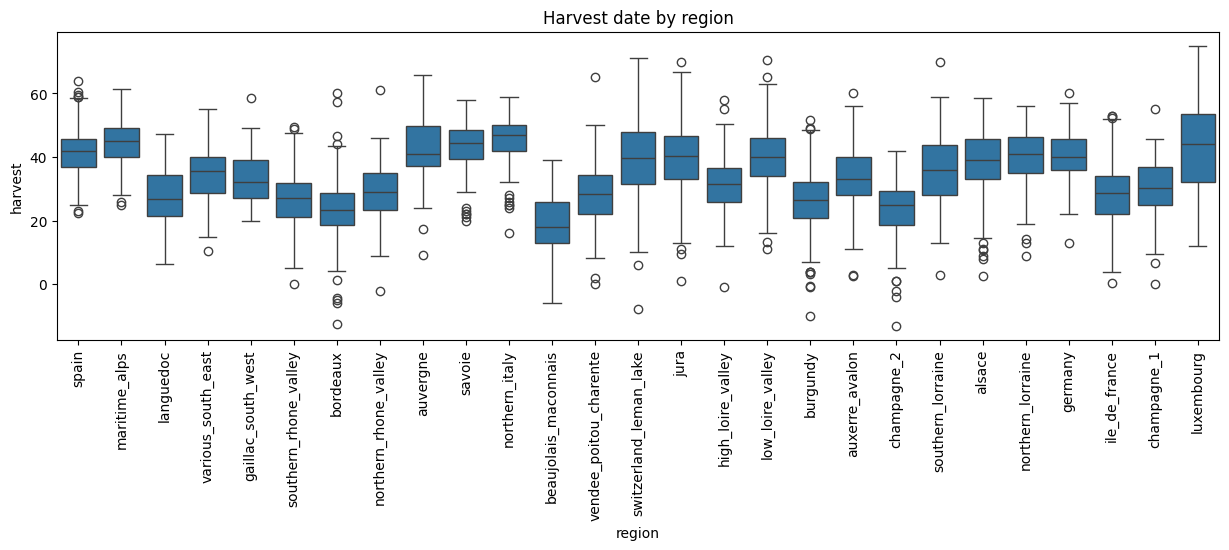

In [31]:
### ANSWER ###
plt.figure(figsize=(15,4))


latitude_order = ['spain','maritime_alps','languedoc','various_south_east','gaillac_south_west','southern_rhone_valley','bordeaux','northern_rhone_valley','auvergne','savoie','northern_italy','beaujolais_maconnais','vendee_poitou_charente','switzerland_leman_lake','jura','high_loire_valley','low_loire_valley','burgundy','auxerre_avalon','champagne_2','southern_lorraine','alsace','northern_lorraine','germany','ile_de_france','champagne_1','luxembourg']

_ = sns.boxplot(x = data['region'], y = data['harvest'], order=latitude_order)
plt.xticks(rotation=90)
# plt.xlabel("region")
# plt.ylabel("harvest date")
plt.title("Harvest date by region")

# Uncomment to save new version of figure. Be sure to upload to the CMSE801 supplemental repository. 
# plt.savefig("harvest_plot.png", bbox_inches = 'tight')

# 1 point for each bullet point 

&#9989; **Question: (6 points)** Based on your graph, answer these questions:

1. What do the black diamonds represent?
2. do you believe that latitude affects the harvest date? Explain your reasoning.
3. If harvest date changes going south to north, how does this impact your analysis of the effect of history and climate change on harvest date? If harvest date is not affected by latitude, what are the implications for your analysis then?

*Put your response here*

In [14]:
### ANSWER
# Each question is graded as such
# 2 points if their answer makes sense. 
# 1 point Grader's discretion.
# 0 point for blank, "I don't know", no reasoning/explanation, if their answer doesn't make sense, or there are logical inconsistencies. 

---
## Part 2: Stars: Exploratory Data Analysis (17 total points)

The first step in every data science project, after obtaining the dataset, is called Exploratory Data Analysis (EDA). As the name suggest it consists in exploring your acquired dataset and look for correlations. 
In the following you are given a dataset containing information about stars. You don't need to know astronomy for this homework and so in the following you will be guided through some steps of a mini data science project. 


### 2.1: Read in the data (2 points)

- Use `pandas` to read the csv file with stars' data, `stars.csv`, and save it into a dataframe called `stars_data`. **(1 point)**
- Print data for the **last 15 stars (1 point)**


In [15]:
# Put your code here

In [16]:
### ANSWER ###
stars_data = pd.read_csv('stars.csv')
stars_data.tail(15) # keep them on their toes. They should always read the text of the problem.

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
225,18734,224780.0,46.0,-7.450,Super Giants,Blue,O
226,9892,593900.0,80.0,-7.262,Super Giants,Blue,O
227,10930,783930.0,25.0,-6.224,Super Giants,Blue,O
228,23095,347820.0,86.0,-5.905,Super Giants,Blue,O
229,21738,748890.0,92.0,-7.346,Super Giants,Blue,O
230,24145,382993.0,1494.0,-8.840,Hyper Giants,Blue-white,B
231,38234,272830.0,1356.0,-9.290,Hyper Giants,Blue,O
232,32489,648430.0,1948.5,-10.840,Hyper Giants,Blue,O
233,27739,849420.0,1252.0,-7.590,Hyper Giants,Blue-white,B
234,21904,748490.0,1130.0,-7.670,Hyper Giants,Blue-white,B


The dataset contains information on 240 stars. The columns are

- Temperature (K): Absolute temperature of the star measured in Kelvin
- Luminosity (L/Lo): Luminosity of the star relative to the luminosity of the sun $L_o = 3.828 \times 10^{26}$ Watts (Avg Luminosity of Sun)
- Radius (R/Ro): Radius of the star relative to the radius of the sun $R_o = 6.9551 \times 10^8$ m (Avg Radius of Sun)
- Absolute Magnitude (Mv): [Absolute Magnitude](https://en.wikipedia.org/wiki/Absolute_magnitude)
- Star type: Type of star. This is a limited dataset with only 6 types = "Red Dwarf", "Brown Dwarf", "White Dwarf", "Main Sequence", "Super Giants", "Hyper Giants"
- Star color: Color of the star
- Spectral Class: [Classification of stars](https://en.wikipedia.org/wiki/Stellar_classification#Modern_classification)


### 2.2 Looking for correlations (2 points)
As you can see there are four columns with numerical values and three columns with string values. Obviously, we can look for correlations only on the first four columns.

&#9989;&nbsp; **Task (1 point):** Print a correlation matrix of the first four columns. _Hint:_ Look up the `corr` function of dataframes.

In [17]:
# Put your code here

In [18]:
### ANSWER
stars_data.corr(numeric_only=True)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv)
Temperature (K),1.000000,0.393404,0.064216,-0.420261
Luminosity(L/Lo),0.393404,1.000000,0.526516,-0.692619
Radius(R/Ro),0.064216,0.526516,1.000000,-0.608728
Absolute magnitude(Mv),-0.420261,-0.692619,-0.608728,1.000000


&#9989;&nbsp; **Question (1 point):** Do you notice any high correlation between columns? 

<font size=8 color="#009600">&#9998;</font> Put your answer here

### ANSWER
Students get full point as long as they answer the question and the answer makes sense. No partial credit.

### 2.3 Grouping by (3 points)

The last three columns of the dataset are there for a reason. Each star is assigned to a class based on its properties.  

&#9989;&nbsp; **Task (1 point):** Run the following cell and explain what you see. 

In [19]:
stars_data.groupby(by = "Star type").corr(numeric_only=True)

Temperature (K)  Luminosity(L/Lo)  \
Star type                                                                 
Brown Dwarf   Temperature (K)                1.000000          0.138601   
              Luminosity(L/Lo)               0.138601          1.000000   
              Radius(R/Ro)                   0.517037         -0.049880   
              Absolute magnitude(Mv)        -0.191694         -0.321309   
Hyper Giants  Temperature (K)                1.000000          0.475826   
              Luminosity(L/Lo)               0.475826          1.000000   
              Radius(R/Ro)                   0.128718          0.112732   
              Absolute magnitude(Mv)         0.251264          0.185925   
Main Sequence Temperature (K)                1.000000          0.802601   
              Luminosity(L/Lo)               0.802601          1.000000   
              Radius(R/Ro)                   0.820268          0.541232   
              Absolute magnitude(Mv)        -0.865062         -0.524928   
Red Dwarf     Temperature (K)                1.000000          0.261838   
              Luminosity(L/Lo)               0.261838          1.000000   
              Radius(R/Ro)                   0.080064         -0.159083   
              Absolute magnitude(Mv)        -0.198101         -0.177093   
Super Giants  Temperature (K)                1.000000          0.252056   
              Luminosity(L/Lo)               0.252056          1.000000   
              Radius(R/Ro)                  -0.066814          0.096616   
              Absolute magnitude(Mv)         0.276887         -0.072840   
White Dwarf   Temperature (K)                1.000000          0.413196   
              Luminosity(L/Lo)               0.413196          1.000000   
              Radius(R/Ro)                   0.180035         -0.130622   
              Absolute magnitude(Mv)        -0.820193         -0.301477   

                                      Radius(R/Ro)  Absolute magnitude(Mv)  
Star type                                                                   
Brown Dwarf   Temperature (K)             0.517037               -0.191694  
              Luminosity(L/Lo)           -0.049880               -0.321309  
              Radius(R/Ro)                1.000000                0.068329  
              Absolute magnitude(Mv)      0.068329                1.000000  
Hyper Giants  Temperature (K)             0.128718                0.251264  
              Luminosity(L/Lo)            0.112732                0.185925  
              Radius(R/Ro)                1.000000               -0.136955  
              Absolute magnitude(Mv)     -0.136955                1.000000  
Main Sequence Temperature (K)             0.820268               -0.865062  
              Luminosity(L/Lo)            0.541232               -0.524928  
              Radius(R/Ro)                1.000000               -0.879941  
              Absolute magnitude(Mv)     -0.879941                1.000000  
Red Dwarf     Temperature (K)             0.080064               -0.198101  
              Luminosity(L/Lo)           -0.159083               -0.177093  
              Radius(R/Ro)                1.000000               -0.120365  
              Absolute magnitude(Mv)     -0.120365                1.000000  
Super Giants  Temperature (K)            -0.066814                0.276887  
              Luminosity(L/Lo)            0.096616               -0.072840  
              Radius(R/Ro)                1.000000                0.013425  
              Absolute magnitude(Mv)      0.013425                1.000000  
White Dwarf   Temperature (K)             0.180035               -0.820193  
              Luminosity(L/Lo)           -0.130622               -0.301477  
              Radius(R/Ro)                1.000000               -0.060761  
              Absolute magnitude(Mv)     -0.060761                1.000000

&#9989;&nbsp; **Task (2 points):** 
1. Explain what you see 
2. Do you notice any difference from the original correlation matrix you printed above?

<font size=8 color="#009600">&#9998;</font> Put your answer here

### ANSWER
1. (1 point) Students get full point as long as they answer the question and the answer makes sense. No partial credit.
2. (1 point) Students get full point as long as they answer the question and the answer makes sense. No partial credit.

### 2.4: Visual representation of correlations (10 points)

The numbers above gives us a quantitative measure of the correlations in the dataset. As you can see Temperature, Luminosity, and Radius become more or less correlated depending on the type of star. In this part we want to visualize the correlations and in the next part we want to model them. 

Visualization in data science is a very important skill!!! The main issue that we see is that we have 7 columns in our dataset, but normal plots can only show two of them at the time. However, there are ways to show three or four columns of data at the same time. (More than four is still possible, however, that plot might be confusing to understand.) 

The way to plot three columns of data at once is to use the x-axis, y-axis, and a color axis. You have done this before, so let's do it again. The x-axis and y-axis will contain numerical values, while the color axis will be used for the type of star. 

We want to make a plot similar to this one

<img src="https://i.ibb.co/rZGfsp5/HR-diagram.png" alt="HR-diagram" border="0" width=950>

&#9989;&nbsp; **Task (6 points):**  Use `matplotlib` and/or `seaborn` to make one figure containing two _scatter plots_ like the ones above. Each plot has the following characteristic
- The entire figure should be 12 inches wide and 6 inches tall **(1 point)**.
- Temperature or Radius on the $x$ -axis and Luminosity on the $y$ -axis **(1 point)**
- Make both the $x$ and $y$ axis **log** scaled **(1 point)**.
- Label the $x$-axis as **Temperature (K)** and the $y$-axis as **Luminosity (L/Lo)** **(1 point)**
- Color the stars based on their star type and label with correct star type. **(1 point)**.
- Show the legend **(1 point)**.

**Side Notes** 
1. The above plot on the left is called the Hertzprung-Russell diagram. For details as to what the Hertzsprung-Russel Diagram is, you can take a look [here](https://astronomy.swin.edu.au/cosmos/h/hertzsprung-russell+diagram). Basically, this is a plot that helps astronomers understand how stars evolve. Over time, individual stars will track out a path on this diagram and when looked at for a whole group of stars, we can use this plot to estimate how old that population of stars might be. If you were to compare your plot with any of the HR diagrams on the internet you would notice that your plot is flipped! This is because the Temperature increases towards the left in those plots!!! You can fix this by adding this line at the end of your code.

    ```plt.gca().invert_xaxis()```
<br>
2. You can choose any color scheme you want as long as it clearly differentiate the type of stars. That means do not make the Red and Brown dwarfs similar color, otherwise you can't differentiate them. The color scheme used in the example plot is given below, if you want to use it. 

In [20]:
# These colors are a personal choice of one of the instructors. 
# You don't have to choose this, you can choose any color scheme you want. 
# If you are interested in knowing more about this color scheme Google "Okabe-Ito color palette"
scolor = ["#CC79A7", "#D55E00", "#0072B2", "#F0E442", "#009E73", "#56B4E9", "#E69F00","#000000"]


# Put your code here

[None, None, Text(0, 0.5, 'Radius (R/Ro)'), Text(0.5, 0, 'Temperature (K)')]

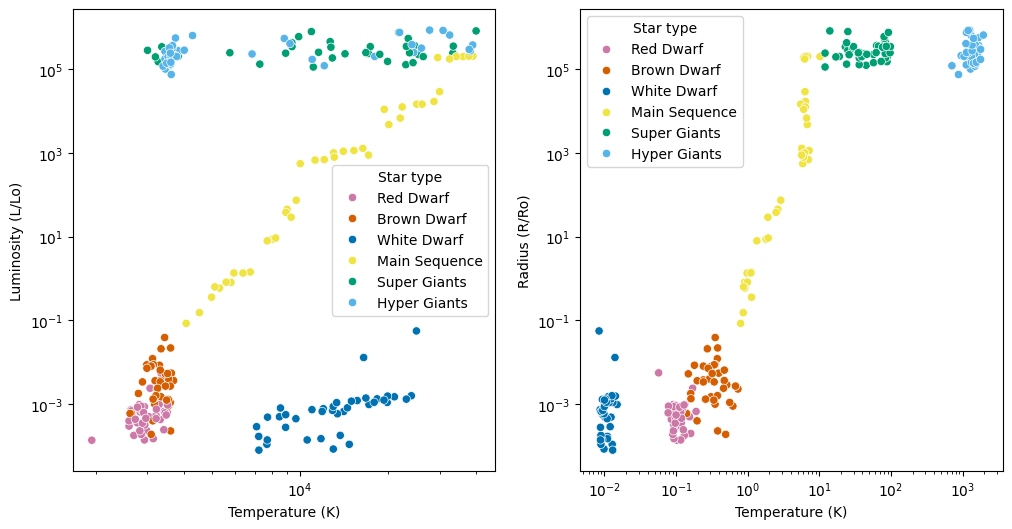

In [21]:
### ANSWER 

# labels = ["Red Dwarf", "Brown Dwarf", "White Dwarf", "Main Sequence", "Super Giants", "Hyper Giants"]

column_str = "Star type"
# scolor = stars_data["Star color"].unique()

labels = stars_data[column_str].unique()


# fig, ax = plt.subplots(1,1, figsize=(10, 7))
fig, ax = plt.subplots(1, 2, figsize = (12,6))
# plt.subplot(121)
# for i in range(len(labels)):
#     sdata = stars_data[stars_data[column_str] == labels[i]] # 2 points for each correct mask and label
#     plt.scatter(sdata["Temperature (K)"], sdata["Luminosity(L/Lo)"], c=scolor[i],  label= labels[i])

sns.scatterplot(data = stars_data, x = "Temperature (K)", y = "Luminosity(L/Lo)", hue = "Star type", palette = scolor[:6], ax = ax[0])
sns.scatterplot(data = stars_data, x = "Radius(R/Ro)", y = "Luminosity(L/Lo)", hue = "Star type", palette = scolor[:6], ax = ax[1])

ax[0].set( yscale ='log', xscale ='log', ylabel ="Luminosity (L/Lo)", xlabel = "Temperature (K)")
ax[1].set( yscale ='log', xscale ='log', ylabel ="Radius (R/Ro)", xlabel = "Temperature (K)")
# ax[0].invert_xaxis()
# ax[1].invert_xaxis()

### ANSWER
The points are given in the text above. Partial credit if only one of the plot has the correct characteristics.

Learning goals: 
- I want students to learn to make good data visualization.


&#9989;&nbsp; **Questions: (4 points)** Looking at the plots, 
1. What are the stars whose Luminosity is highly correlated with Temperature and Radius? (1 point)
2. Now that you've looked at the two plots, which of the two plots suggested that astronomers use the names: "Red Dwarf", "Brown Dwarf", "White Dwarf", "Main Sequence", "Super Giants", "Hyper Giants"? (1 point)
3. Looking at the main sequence stars. Which plot has the largest slope? Justify your answer and look carefully at the range of values the data span. (2 points)

<font size=8 color="#009600">&#9998;</font> Put your answer here

### ANSWER
1. (1 point) Main sequence. No partial credit.
2. (1 point) Radius vs Luminosity. No partial credit.
3. 0 points if blank, 
    0.5 points if they attempt it, but are way off or no justification, 
    1.0 point for answering but justification is confusing or contraddicting, 
    1.5 points if the answer is good, but is still missing that one thing. 
    2 points Good answer. Temp vs Lum. The main sequence stars span 2 orders of magnitude in Temperature, and barely one in radius.


---
## Part 3: Fitting curves to data. The Luminosity Function (16 points)

Now that we have visualized our data we can formulate our question. 

> What is the relation between Luminosity, Temperature, and Radius?

In the following we will try to find this relation.


### 3.1: Choosing a model (6 points)
In the above plots we notice that the main sequence stars fall on a (almost) straight line in both plots. Since both axis are on a log-log plot we can infer that there exist a power-law relation between the Luminosity, $L$, Temperature, $T$ and radius, $R$. Specifically, 

$$ L  = A R^{\alpha} T^{\beta} $$

For the sake of simplicity, we will try to model only the relation between Luminosity and Temperature. In order to simplify the above equation we look at the description of our data. Notice that the Luminosity is a relative quantity, _i.e._ we have information of the ratio between the real luminosity divided (normalized) by the luminosity of the sun, $L_o = 3.828 \times 10^{26}$. Therefore, it would be better to compare the relative luminosity with the relative temperature. The relation now becomes

$$ \frac{L}{L_o} = \left( \frac{T}{T_o} \right )^{\beta} $$ 

where $T_o = 5780$ K is the temperature of the sun. 

&#9989;&nbsp; **Task (6 points):** 
- Add a new column to your dataset and call it `Normalized Temperature`. This column is obtained by dividing the `Temperature (K)` column by the temperature of the sun $T_o = 5780$ K. (2 points)
- Write a function called `lum_model` that computes the relative luminosity according to the equation above (i.e. $\left( \frac{T}{T_o} \right )^{\beta}$). Remember, you now have a new column that is the normalized temperature, $\frac{T}{T_0}$, so this simplifies your function and you don't need to worry about doing the normalization inside the function if you give it the right temperature data. (4 points)

In [22]:
# Put your code here

In [23]:
### ANSWER ###
Tsun = 5780
stars_data["Normalized Temperature"] = stars_data["Temperature (K)"]/Tsun
# 1 point for correct math + 1 point for adding it to the dataframe.

def lum_model(T, beta):
    return  T**beta

# 1 point for correct name
# 1 point for correct order of the inputs. No partial credit
# 1 point for correct math. No partial credit
# 1 points for return statement

### 3.2: Fit the model (7 points)

&#9989;&nbsp; **Task:** 

- Now use `curve_fit` with the above function to find the parameter $\beta$ by fitting the `Luminosity(L/Lo)` and `Normalized Temperature` of the **main sequence stars only** (you'll want to use a mask to select these stars).

- What is the value of $\beta$?

In [24]:
# Put your code here

In [25]:
### ANSWER ###
mask = stars_data["Star type"] == "Main Sequence"
main_sequence = stars_data[mask]

popt, pcov = curve_fit(lum_model, 
                       main_sequence["Normalized Temperature"], 
                       main_sequence["Luminosity(L/Lo)"])

# 1 point for selecting only the main sequence stars. They can use a mask or whatever they want.
# 1 point for calling curve_fit
# 1 point for correct placement of lum model
# 1 point for correct placement of y values (temperature)
# 1 point for correct placement of x values (luminosity)
# 1 point for assigning outputs (popt, pcov)

print(popt)
# 1 point for printing beta


[6.56193337]


### 3.3 Check your model (3 points)

&#9989;&nbsp; **Task (3 points):**  Make a plot comparing your model and the data. Don't forget to log-scale your axis, label them, and add a legend.

In [26]:
# Put your code here

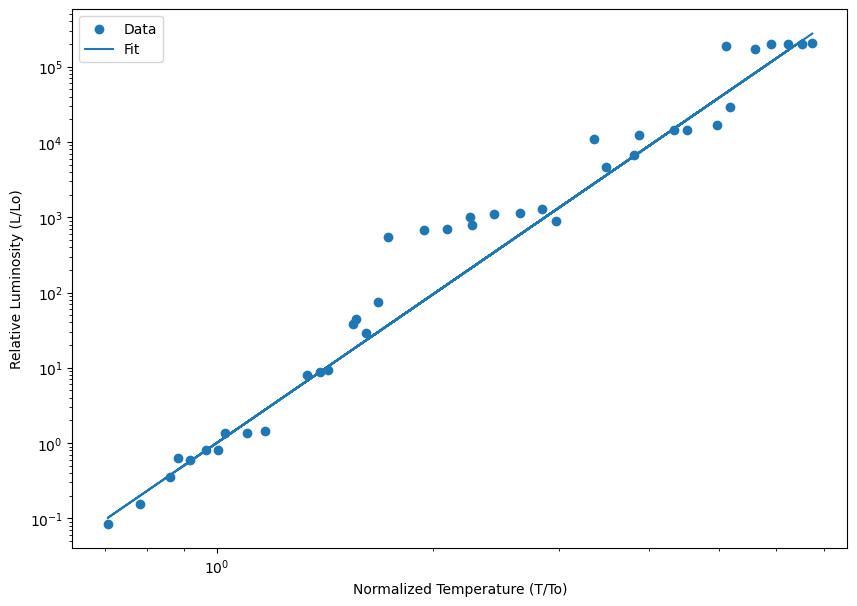

In [27]:
### ANSWER
# 1 point for plotting the data. No partial credit
# 1 point for plotting the fitted curve. No partial credit
# 1 point for labeling the figure (x and y axis, log scaled, legend). Partial credit if only legend missing. 0 points if no x-y labels but legend is present. They should always have labels on their axis

x_col = "Normalized Temperature"
y_col = "Luminosity(L/Lo)"
fig, ax = plt.subplots(1,1, figsize=(10, 7))

ax.scatter(main_sequence["Normalized Temperature"], main_sequence["Luminosity(L/Lo)"], label = "Data")
ax.plot( main_sequence["Normalized Temperature"], 
          lum_model( main_sequence["Normalized Temperature"], *popt), label = "Fit")

ax.set( yscale ='log', xscale ='log', ylabel ="Relative Luminosity (L/Lo)", xlabel = "Normalized Temperature (T/To)")
ax.legend()
# ax.invert_xaxis()

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Homework Assignments" folder, find the submission link for Homework 4, and upload it there.

&#169; 2026 Copyright the Department of Computational Mathematics, Science and Engineering.